# Titanic Modeling — Zepto Data & AI Platform Capstone

Reads the committed `titanic.csv` (never calls `sns.load_dataset` again -- that
happened exactly once, in `01_eda.ipynb`). Drops leakage and duplicate/derived
columns, builds a stratified train/test split, and a leakage-safe preprocessing
pipeline fit only on the training data.


In [1]:
import pandas as pd

df = pd.read_csv("titanic.csv")
print(df.shape)
df.head()


(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Dropping leakage and duplicate/derived columns

- **`alive` -- DROPPED. This is target leakage.** It is literally `survived`
  recoded as `yes`/`no` text. If it stayed in the feature matrix, every
  classifier would score ~100% by reading the answer directly instead of
  learning anything -- the single most dangerous trap in this project.
- **`class` -- dropped.** Duplicates `pclass` as text (1/2/3 vs "First"/
  "Second"/"Third").
- **`who`, `adult_male` -- dropped.** Both are derived directly from `sex` and
  `age`, which are already features -- they add no new information, just a
  different encoding of columns already present.
- **`embark_town` -- dropped.** Duplicates `embarked` (full town name vs the
  single-letter code).
- **`alone` -- dropped.** Derived directly from `sibsp` + `parch` (both already
  features).
- **`deck` -- dropped.** 77.22% missing (measured in `01_eda.ipynb`) -- too
  sparse to impute or encode reliably as a model feature.

Remaining features: `pclass, sex, age, sibsp, parch, fare, embarked`. Target:
`survived`.


In [2]:
columns_to_drop = ["alive", "class", "who", "adult_male", "embark_town", "alone", "deck"]
df_model = df.drop(columns=columns_to_drop)

print(df_model.shape)
df_model.dtypes


(891, 8)


survived      int64
pclass        int64
sex             str
age         float64
sibsp         int64
parch         int64
fare        float64
embarked        str
dtype: object

## Stratified train/test split

`survived` is moderately imbalanced (roughly 38% survived / 62% did not, from
the EDA profile). A plain random split could by chance skew that ratio
differently between train and test, especially on the smaller test set --
stratification guarantees both splits preserve the same ~38/62 balance, which
is confirmed numerically below.


In [3]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["survived"])
y = df_model["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True))


Train class balance:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Test class balance:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


## Preprocessing: ColumnTransformer inside a Pipeline

Numeric features (`pclass, age, fare, sibsp, parch`) get median imputation then
`StandardScaler`. Categorical features (`sex, embarked`) get most-frequent
imputation then one-hot encoding. Both are fit ONLY on `X_train` below.


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ["pclass", "age", "fare", "sibsp", "parch"]
categorical_features = ["sex", "embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [5]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("X_train_transformed shape:", X_train_transformed.shape)
print("X_test_transformed shape:", X_test_transformed.shape)

feature_names = preprocessor.get_feature_names_out()
print("\nFeature names after preprocessing:")
print(list(feature_names))


X_train_transformed shape: (712, 10)
X_test_transformed shape: (179, 10)

Feature names after preprocessing:
['num__pclass', 'num__age', 'num__fare', 'num__sibsp', 'num__parch', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S']


## Three classifiers on the identical split

LogisticRegression, DecisionTree, RandomForest -- each wrapped in its own full
Pipeline (preprocessing + classifier), trained on the same `X_train`/`y_train`.


In [6]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

fitted_pipelines = {}

for name, classifier in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", classifier),
    ])
    pipeline.fit(X_train, y_train)
    fitted_pipelines[name] = pipeline
    print(f"{name}: fitted")


Logistic Regression: fitted
Decision Tree: fitted
Random Forest: fitted


## Decision tree visualization

Rendered with `plot_tree`, feature names and class names labeled. Shown to
depth 3 for readability -- the trained model itself is NOT depth-limited, only
the picture is truncated.


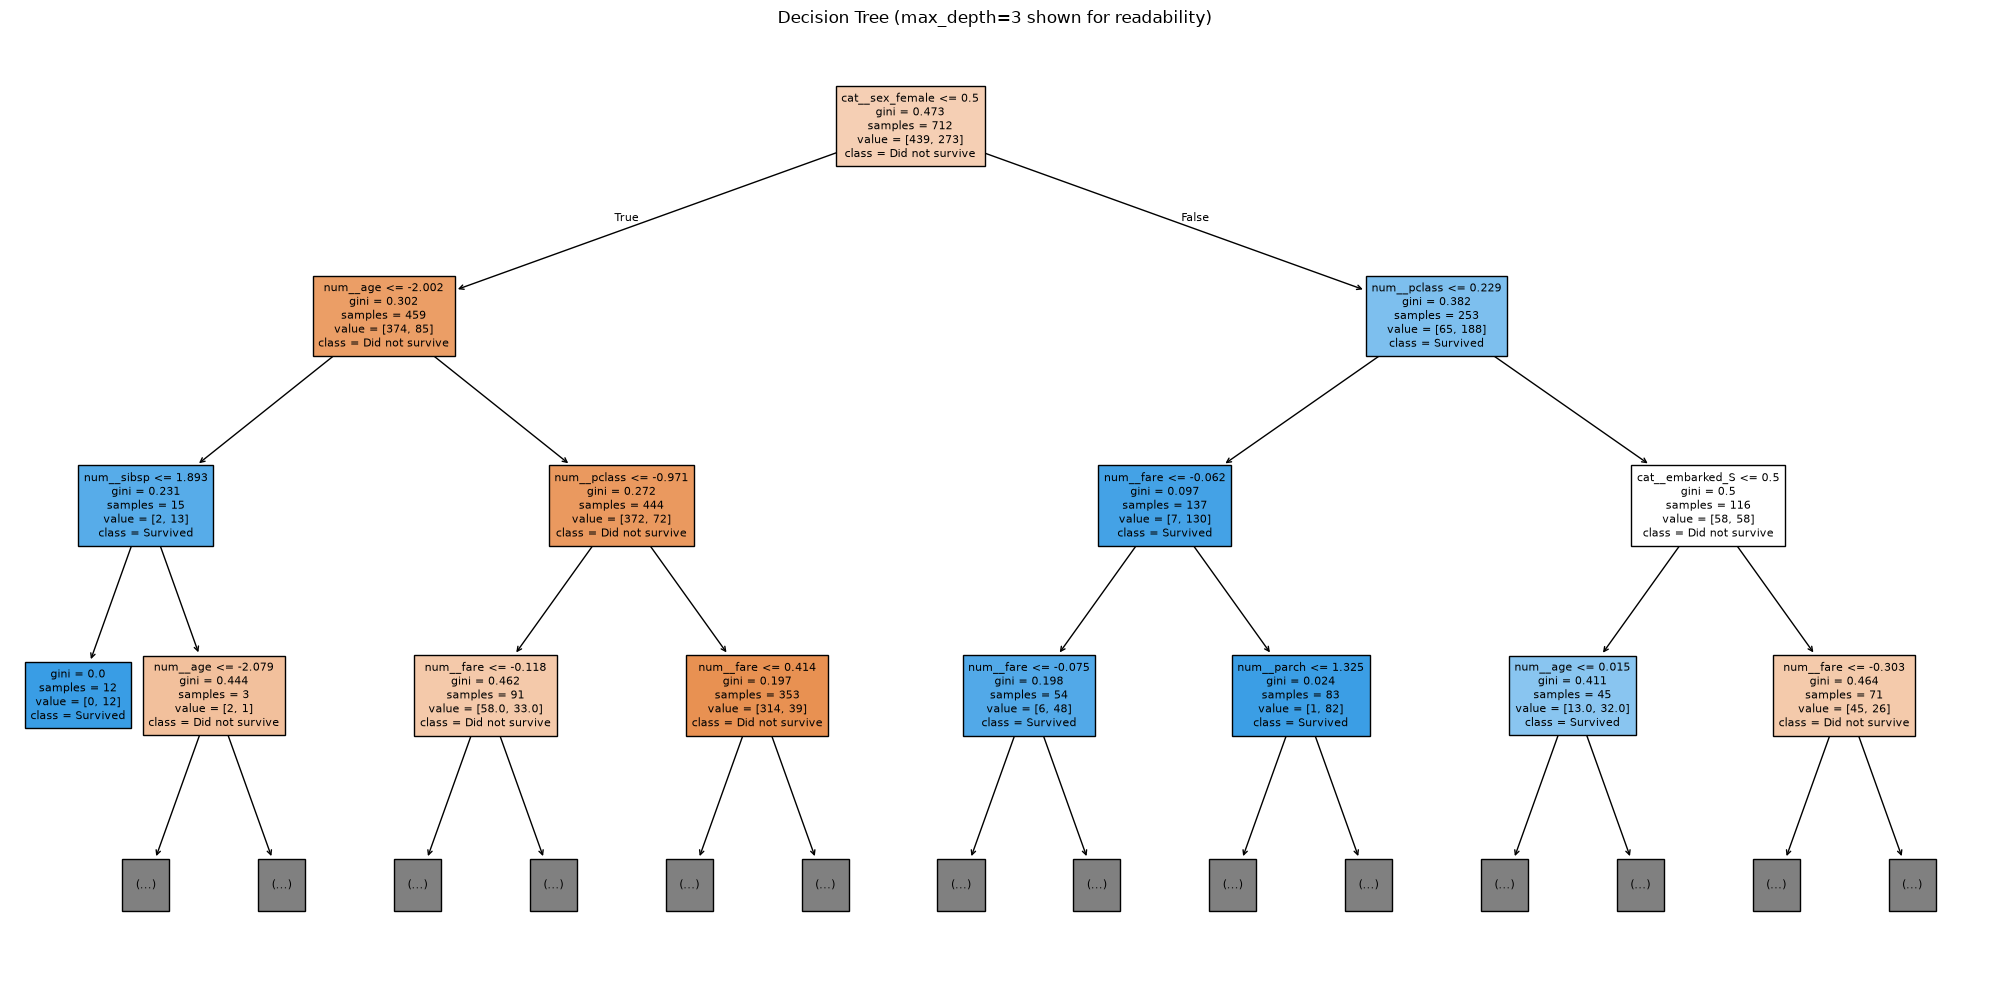

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dt_pipeline = fitted_pipelines["Decision Tree"]
dt_classifier = dt_pipeline.named_steps["classifier"]
feature_names_out = dt_pipeline.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    dt_classifier,
    feature_names=feature_names_out,
    class_names=["Did not survive", "Survived"],
    filled=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Decision Tree (max_depth=3 shown for readability)")
plt.tight_layout()
plt.savefig("charts/decision_tree.png", dpi=100)
plt.show()


## Metrics: confusion matrix, accuracy, precision, recall, F1, ROC/AUC


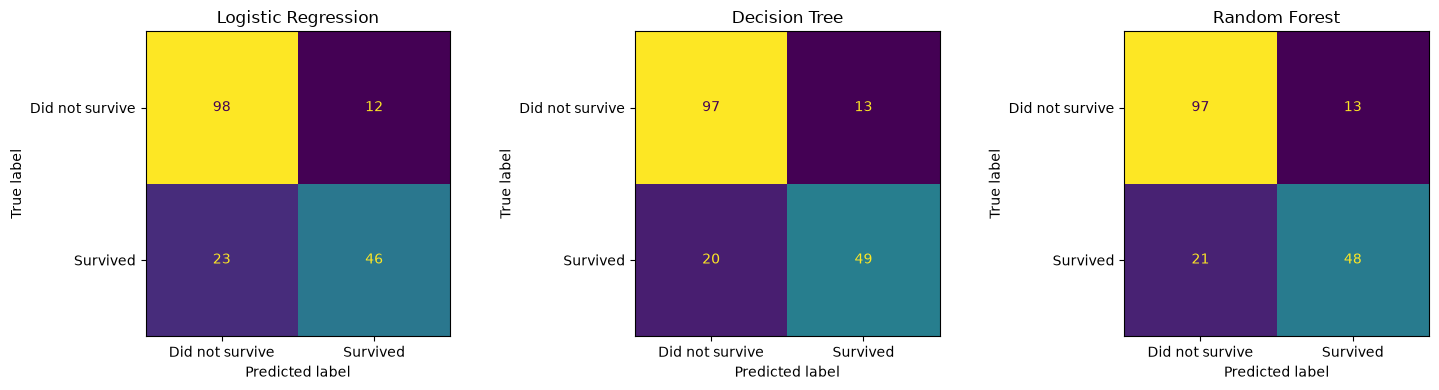

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
Decision Tree,0.815642,0.790323,0.710145,0.748092,0.790382
Random Forest,0.810056,0.786885,0.695652,0.738462,0.826219


In [10]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)

results = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, pipeline) in enumerate(fitted_pipelines.items()):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name, "Accuracy": accuracy, "Precision": precision,
        "Recall": recall, "F1": f1, "AUC": auc,
    })

    ConfusionMatrixDisplay(cm, display_labels=["Did not survive", "Survived"]).plot(ax=axes[idx], colorbar=False)
    axes[idx].set_title(name)

plt.tight_layout()
plt.savefig("charts/confusion_matrices.png", dpi=100)
plt.show()

results_df = pd.DataFrame(results).set_index("Model")
results_df


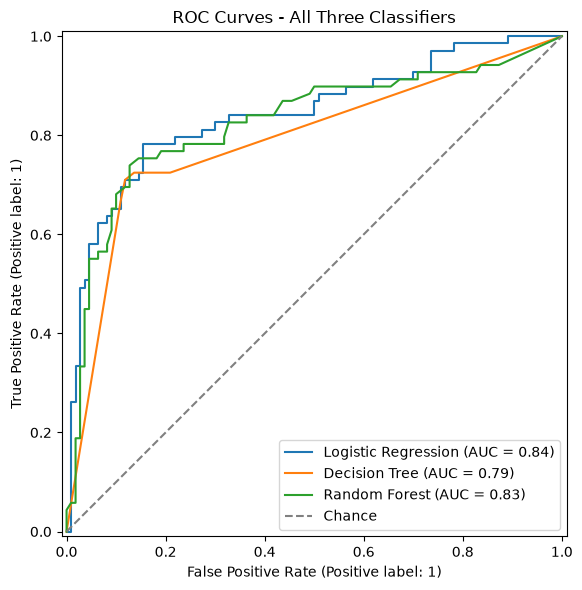

In [11]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 6))
for name, pipeline in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curves - All Three Classifiers")
ax.legend()
plt.tight_layout()
plt.savefig("charts/roc_curves.png", dpi=100)
plt.show()


## Imbalance comparison: baseline vs. class_weight='balanced' vs. SMOTE

Class balance in the training data (from S10): ~61.7% did not survive, ~38.3%
survived -- moderate imbalance. Comparing three ways of handling it with the
same Random Forest classifier. SMOTE is applied to the training fold only, via
`imblearn.pipeline.Pipeline`.


In [12]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1. Baseline: reuse the Random Forest pipeline already fitted in S11.
baseline_pipeline = fitted_pipelines["Random Forest"]
baseline_pred = baseline_pipeline.predict(X_test)

# 2. class_weight='balanced'
balanced_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42)),
])
balanced_pipeline.fit(X_train, y_train)
balanced_pred = balanced_pipeline.predict(X_test)

# 3. SMOTE on the training fold only -- imblearn.pipeline.Pipeline resamples
# only during .fit(), never during .predict(), so the test fold is untouched.
smote_pipeline = ImbPipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42)),
])
smote_pipeline.fit(X_train, y_train)
smote_pred = smote_pipeline.predict(X_test)

print("Fitted all three variants.")


Fitted all three variants.


In [13]:
imbalance_results = []
for name, y_pred in [
    ("Baseline", baseline_pred),
    ("class_weight=balanced", balanced_pred),
    ("SMOTE", smote_pred),
]:
    imbalance_results.append({
        "Strategy": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    })

imbalance_df = pd.DataFrame(imbalance_results).set_index("Strategy")
imbalance_df


,Precision,Recall,F1
Strategy,,,
Baseline,0.786885,0.695652,0.738462
class_weight=balanced,0.765625,0.710145,0.736842
SMOTE,0.750000,0.739130,0.744526


## GridSearchCV over RandomForest, with OOB score

Tuning `n_estimators`, `max_depth`, `max_features` via 5-fold cross-validation
on the training data. The estimator is constructed with `oob_score=True,
bootstrap=True` so `oob_score_` is available after fitting.


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"],
}

grid_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(oob_score=True, bootstrap=True, random_state=42)),
])

grid_search = GridSearchCV(grid_pipeline, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_.named_steps["classifier"]
print("OOB score:", best_rf.oob_score_)


Best params: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 300}
Best CV F1 score: 0.7482195152517732
OOB score: 0.8300561797752809


### Conclusion: imbalance handling

Moving from baseline to `class_weight='balanced'` to SMOTE trades precision for
recall in a consistent progression: precision falls from 0.7869 (baseline) to
0.7656 (balanced) to 0.7500 (SMOTE), while recall rises from 0.6957 to 0.7101
to 0.7391 over the same sequence. **SMOTE gives the best F1 (0.7445)**, edging
out the baseline (0.7385) and `class_weight='balanced'` (0.7368). For this
problem, catching more true survivors (higher recall) at a modest precision
cost is a reasonable trade -- missing a passenger who actually survived is a
different kind of error than a false alarm, and SMOTE's synthetic oversampling
of the minority class gives the clearest overall balance of the three
strategies here.


### GridSearchCV results

Best parameters: `max_depth=5, max_features='sqrt', n_estimators=300`, with a
5-fold cross-validated F1 of 0.7482 -- slightly better than any single strategy
in the imbalance comparison above, confirming that constraining tree depth
(the untuned baseline had no depth limit) reduces overfitting on this dataset.

The OOB score is 0.8301. Note this is a different metric than the grid
search's F1 -- `oob_score_` defaults to mean accuracy on the out-of-bag
samples, not F1 -- so the two numbers are not directly comparable, but both
independently suggest the tuned forest generalizes reasonably well without
needing a separate validation set.


## Regression sub-task: predicting fare

A separate task from classification -- `fare` is now the TARGET, predicted from
`pclass, sex, age, sibsp, parch, embarked, survived`. This uses its own
train/test split and its own preprocessing pipeline (not the classification
one), keeping the two tasks' feature sets explicitly separate.


In [16]:
from sklearn.linear_model import LinearRegression

X_reg = df_model.drop(columns=["fare"])
y_reg = df_model["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

numeric_features_reg = ["pclass", "age", "sibsp", "parch", "survived"]
categorical_features_reg = ["sex", "embarked"]

numeric_transformer_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_reg = ColumnTransformer(transformers=[
    ("num", numeric_transformer_reg, numeric_features_reg),
    ("cat", categorical_transformer_reg, categorical_features_reg),
])

regression_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_reg),
    ("regressor", LinearRegression()),
])
regression_pipeline.fit(X_reg_train, y_reg_train)

y_reg_pred = regression_pipeline.predict(X_reg_test)

feature_names_reg = regression_pipeline.named_steps["preprocessor"].get_feature_names_out()
print("Predictors after encoding:", list(feature_names_reg))
print("p =", len(feature_names_reg))


Predictors after encoding: ['num__pclass', 'num__age', 'num__sibsp', 'num__parch', 'num__survived', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S']
p = 10


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

n = len(y_reg_test)
p = len(feature_names_reg)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = mean_squared_error(y_reg_test, y_reg_pred) ** 0.5
r2 = r2_score(y_reg_test, y_reg_pred)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"n (test rows): {n}")
print(f"p (predictors after encoding): {p}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")


n (test rows): 179
p (predictors after encoding): 10
MAE: 20.8977
RMSE: 30.5328
R2: 0.3975
Adjusted R2: 0.3617


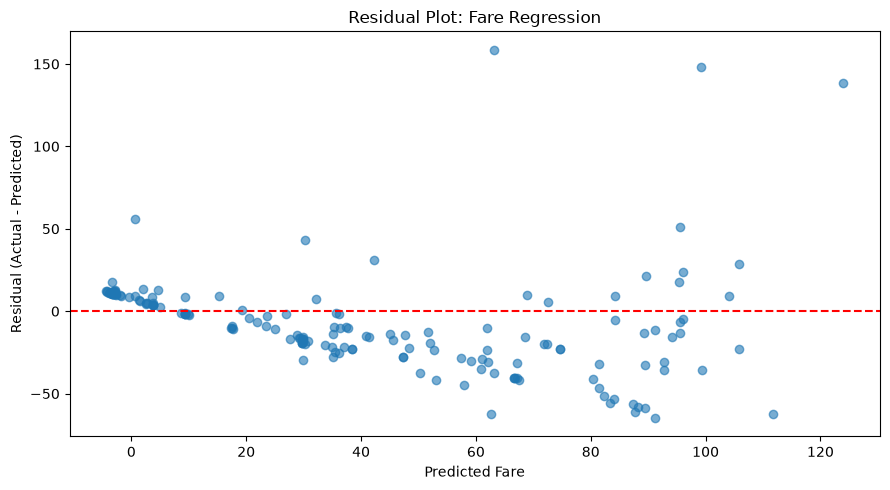

In [18]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(9, 5))
plt.scatter(y_reg_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot: Fare Regression")
plt.tight_layout()
plt.savefig("charts/fare_regression_residuals.png", dpi=100)
plt.show()


### Regression results and heteroscedasticity verdict

| Metric | Value |
|---|---|
| n (test rows) | 179 |
| p (predictors after encoding) | 10 |
| MAE | 20.90 |
| RMSE | 30.53 |
| R² | 0.3975 |
| Adjusted R² | 0.3617 |

The model explains about 40% of fare's variance (R² = 0.3975), dropping to
36.17% once adjusted for the 10 predictors used -- a real but limited amount of
explanatory power, consistent with fare being driven partly by factors this
dataset doesn't capture (specific cabin, exact ticket type, etc.).

**Heteroscedasticity: present.** The residual plot shows a clear funnel shape --
residuals are tightly clustered near zero for low predicted fares (roughly
±10-20 in the 0-20 predicted-fare range), then spread dramatically wider
(-65 to +160) as predicted fare rises past 60. This means the model's errors
are NOT uniform across the fare range: it predicts cheap tickets fairly
precisely but is far less reliable for expensive ones. This makes sense given
fare's strong right skew (established in the univariate analysis in
`01_eda.ipynb`) -- a linear model fit on a heavily skewed target tends to
underfit the sparse, extreme high-value tail, producing exactly this kind of
widening error pattern.


## Final comparison: classifier vs. regression metrics

Kept as two separate tables, not one merged scale -- an F1 of 0.75 and an R² of
0.40 measure fundamentally different things and are not comparable numbers.


In [19]:
print("=== Classification metrics (3 classifiers, test set) ===")
print(results_df)


=== Classification metrics (3 classifiers, test set) ===
                     Accuracy  Precision    Recall        F1       AUC
Model                                                                 
Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
Decision Tree        0.815642   0.790323  0.710145  0.748092  0.790382
Random Forest        0.810056   0.786885  0.695652  0.738462  0.826219


In [20]:
regression_metrics_df = pd.DataFrame({
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted R2": [adj_r2],
}, index=["Linear Regression (fare)"])

print("=== Regression metrics (fare prediction, test set) ===")
print(regression_metrics_df)


=== Regression metrics (fare prediction, test set) ===
                                MAE       RMSE        R2  Adjusted R2
Linear Regression (fare)  20.897718  30.532803  0.397548     0.361688


### Deployment recommendation

For predicting survival, the **tuned Random Forest with SMOTE** is recommended:
GridSearchCV found `max_depth=5, max_features='sqrt', n_estimators=300` (5-fold
CV F1 = 0.7482, OOB = 0.8301), and applying SMOTE to that configuration's
training fold gives the best test-set F1 (0.7445) and strongest recall
(0.7391) of every variant tested, meaningfully ahead of the untuned baseline
Random Forest (F1 = 0.7385). Logistic Regression keeps the highest AUC
(0.8437) and highest precision (0.7931), so it would be the better choice if
threshold-independent ranking mattered most or false alarms were especially
costly -- but at a fixed 0.5 threshold its recall (0.6667) is the weakest of
the three, missing more true survivors than the tuned forest does. The
Decision Tree is the easiest model to explain to a non-technical audience but
trails on AUC (0.7904 vs. Random Forest's 0.8262) despite a comparable F1,
making it a reasonable interpretability trade-off rather than the top
performer. For fare prediction, the linear regression model explains only
39.75% of variance (Adjusted R² = 0.3617) and shows clear heteroscedasticity,
so it should be treated as a rough estimate only -- not deployed anywhere
precise fare prediction matters, particularly for higher-value tickets where
its errors are largest.